## Mini Chess Solver Using Dynamic Programming - Total 7 Marks

### Problem Statement

Design and implement a reinforcement learning agent using dynamic programming (value iteration or policy iteration) to compute an optimal policy for a simplified chess game. The agent plays as White and must learn how to convert an advantage into a win or at least avoid a loss in a MiniChess game against a defensive opponent. The problem must be modelled as a finite MDP. Register number of first student in a group (alphabetically sorted) will be considered for configuration design.
The student will:
* Implement a custom Mini Chess environment.
* Use dynamic programming to compute the optimal value function and policy.
* Analyze how state design and reward shaping affect the learned policy and convergence.

### Scenario

You are building a “Mini Chess Game” for beginner players. The coach focuses on a small, tractable game:
* White: King + Pawn
* Black: King
* Board: 4×4 or 5×5 MiniChess board
* White moves first and tries to either:
    * Promote the pawn and then deliver checkmate, or
    * Force a checkmate directly (if possible)

Black tries to prevent this by blocking the pawn, chasing the white king, or capturing the pawn. The game is restricted to this small set of pieces and a tiny board.

### Environment Description
#### Board and Pieces
* Board size:
    * If the student roll number / registration number is even: use a 4×4 board (rows 0–3, cols 0–3).
    * If odd: use a 5×5 board (rows 0–4, cols 0–4).
* Pieces always present:
    * White King (WK)
    * White Pawn (WP)
    * Black King (BK)
    * No castling, no en passant, no promotion to anything other than Queen.
* Legal Moves
    * Kings move like normal chess kings - one square in any direction (8- neighborhood), staying on the board.
    * Pawn:
        * Moves one square forward (towards larger row index or smaller row index – the student must choose and clearly document a convention).
        * Captures diagonally forward by one square.
    * All usual constraints apply:
        * Kings cannot move into check.
        * Two kings may never occupy adjacent squares (illegal state).
        * A piece cannot move through other pieces.
* Episode Termination
    * An episode ends when any of the following happens:
        * Checkmate (White checkmates Black).
        * Stalemate (side to move has no legal moves but is not in check).
        * Pawn Capture (Black captures the White pawn).
        * Pawn Promotion (White pawn reaches last rank and becomes a Queen). After promotion, they may either:
                * (a) terminate immediately with a reward, or
                * (b) continue playing with a Queen replacing the pawn.
        * The student must choose one approach and justify it.
        * Move limit exceeded (e.g., 20 or 30 plies) – draw
1. State Space

* Each state should minimally encode:
    * Coordinates of WK: (r_wk, c_wk)
    * Coordinates of WP (or a special value if promoted/captured): (r_wp, c_wp) or status flag
    * Coordinates of BK: (r_bk, c_bk)
    * Player to move: {White, Black}
    * Any additional flags that can be necessary like,
        * Has the pawn promoted?
        * Check / checkmate / stalemate indicators.
* The student must:
    * Describe the state representation clearly.
2. Action Space
    * For each state, actions are the legal moves for the side to move:
        * Move King to a legal square
        * Move Pawn / promoted Queen
    * The student must implement a function that, given a state, returns all legal actions.
3. Rewards
* The student has to define the reward schemes like:
    * White checkmates Black: +10
    * Pawn gets captured: -10
    * Stalemate or draw by move limit: 0
    * All non-terminal moves: 0

## Part 0 : State Representation and Design Choices

**State Representation:**

`State = (WK, WP, BK, Turn, Promoted, Plies)`

|State | Values | Description |
|---------|----------|-----|
|WK        → |(r_wk, c_wk)|   White King position|
|WP        → |(r_wp, c_wp)|  White Pawn position or None if captured|
|BK        → |(r_bk, c_bk)|  Black King position|
|Turn      → |'W' or 'B'  |   Player to move|
|Promoted  → |True / False|  Pawn promoted to Queen|
|Plies     → |Integer     |    Half-move counter|


<ins>**Board Configuration (Even Registration Number)**</ins>

* Since the registration number <ins>**202405320**</ins> is **even**, a **4X4** board is used.

* Initial setup:
  * White King and Black King are placed on opposite corners.
  * White Pawn is placed on the rank closest to the White King.
* White always moves first.

<ins>**Pawn Promotion and Termination:**</ins>

* When the pawn reaches the final rank, it is **promoted to a Queen**, and the game **continues**.

* An episode ends if:
  * The pawn is captured,
  * Checkmate or stalemate occurs,
  * The maximum move limit is reached (30 plies).

<ins>**Dynamic Programming Methods:**</ins>

* Both **Value Iteration** and **Policy Iteration** are implemented.
* Value Iteration computes the optimal value function.
* Policy Iteration is used for comparison and converges to a similar optimal policy.

<ins>**Action Space Design:**</ins>

| Player | Piece | Allowed Actions                                                            |
| ------ | ----- | -------------------------------------------------------------------------- |
| White  | King  | Move one square in any direction (legal squares only)                      |
| White  | Pawn  | Move one square forward (before promotion)                                 |
| White  | Queen | Move any number of squares in straight or diagonal lines (after promotion) |
| Black  | King  | Move one square in any direction (legal squares only)                      |

* All chess constraints are enforced:
  * Kings cannot be adjacent.
  * Kings cannot move into check.
  * Moves must remain inside the board.

<ins>**Reward Design:**<ins>

| Situation                       | Reward |
| ------------------------------- | ------ |
| White checkmates Black          | +10    |
| White pawn is captured          | −10    |
| Stalemate or move limit reached | 0      |
| All non-terminal moves          | 0      |




## Part 1 : Import Statements

In [3]:
# Import Statements
import itertools
import math
import time
from collections import deque, defaultdict
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional, Iterable, Any


import numpy as np
import matplotlib.pyplot as plt

## Part 2 : Basic types and helpers (State & Action)

In [4]:
@dataclass(frozen=True)
class State:
    """
    Immutable state representation for MiniChess.
    """
    wk: Tuple[int, int]                     # White King position
    wp: Optional[Tuple[int, int]]           # White Pawn / Queen position or None
    bk: Tuple[int, int]                     # Black King position
    turn: str                               # 'W' or 'B'
    promoted: bool                          # Pawn promoted to Queen?
    plies: int                              # Half-move count

    def as_tuple(self):
        return (self.wk, self.wp, self.bk, self.to_move, self.promoted)

@dataclass(frozen=True)
class Action:
    """
    Represents a single chess move.
    """
    piece: str                              # 'K', 'P', or 'Q'
    from_pos: Tuple[int, int]
    to_pos: Tuple[int, int]

    def as_tuple(self):
        return (self.piece, self.src, self.dst)

def chebyshev_dist(a: Tuple[int, int], b: Tuple[int, int]) -> int:
    """Distance used for king adjacency."""
    return max(abs(a[0] - b[0]), abs(a[1] - b[1]))

## Part 3 : MiniChess Environment

In [5]:
# Define the MiniChess Environment - 1.5 mark
class MiniChessEnv:
  """
    MiniChess Environment (4x4 board for even Reg. No (2024AC05320)).
    White: King + Pawn (can promote to Queen)
    Black: King
  """

  def __init__(self, board_size: int = 4, max_plies: int = 30):
        self.N = board_size
        self.max_plies = max_plies

        self.king_dirs = [
            (dr, dc)
            for dr in (-1, 0, 1)
            for dc in (-1, 0, 1)
            if not (dr == 0 and dc == 0)
        ]

        self.queen_dirs = [
            (1, 0), (-1, 0), (0, 1), (0, -1),
            (1, 1), (1, -1), (-1, 1), (-1, -1)
        ]

        # Reward scheme (sparse)
        self.R_MATE = 10.0
        self.R_PAWN_CAPTURE = -10.0
        self.R_DRAW = 0.0

  # --------------------------------------------------------
  # Board & Positions Fuction
  # --------------------------------------------------------

  def on_board(self, pos: Tuple[int, int]) -> bool:
        r, c = pos
        return 0 <= r < self.N and 0 <= c < self.N

  def kings_adjacent(self, wk: Tuple[int, int], bk: Tuple[int, int]) -> bool:
        return chebyshev_dist(wk, bk) <= 1

  # --------------------------------------------------------
  # Move generation
  # --------------------------------------------------------

  def king_moves(self, pos: Tuple[int, int], state: State) -> List[Tuple[int, int]]:
      """
      Legal king moves for the king located at `pos`.
      """
      side = 'W' if pos == state.wk else 'B'
      moves = []

      for dr, dc in self.king_dirs:
          nr, nc = pos[0] + dr, pos[1] + dc
          dest = (nr, nc)

          if not self.on_board(dest):
              continue

          new_wk = dest if side == 'W' else state.wk
          new_bk = dest if side == 'B' else state.bk

          # Kings cannot be adjacent
          if self.kings_adjacent(new_wk, new_bk):
              continue

          # Cannot capture opposing king directly
          if side == 'W' and dest == state.bk:
              continue

          temp_state = State(
              wk=new_wk,
              wp=state.wp,
              bk=new_bk,
              turn='B' if side == 'W' else 'W',
              promoted=state.promoted,
              plies=state.plies + 1
          )

          # Cannot move into check
          if self.in_check(temp_state, side):
              continue

          moves.append(dest)

      return moves

  # --------------------------------------------------------

  def pawn_moves(self, state: State) -> List[Tuple[int, int]]:
      """
      Pawn forward moves (no captures needed in this setup).
      """
      if state.wp is None:
          return []

      r, c = state.wp
      dest = (r - 1, c)

      if self.on_board(dest) and dest not in (state.wk, state.bk):
          return [dest]

      return []

  # --------------------------------------------------------

  def queen_moves(self, qpos: Tuple[int, int], state: State) -> List[Tuple[int, int]]:
      """
      Queen moves after promotion.
      """
      moves = []

      for dr, dc in self.queen_dirs:
          r, c = qpos
          while True:
              r += dr
              c += dc
              dest = (r, c)

              if not self.on_board(dest):
                  break
              if dest in (state.wk, state.wp, state.bk):
                  break

              moves.append(dest)

      return moves

  # --------------------------------------------------------
  # Check detection: For game rules and legality checks
  # --------------------------------------------------------

  def in_check(self, state: State, side: str) -> bool:
      """
      Check detection.
      """
      if side == 'W':
          return chebyshev_dist(state.wk, state.bk) == 1

      # Black in check by White
      if chebyshev_dist(state.wk, state.bk) == 1:
          return True

      if state.wp is not None and not state.promoted:
          pr, pc = state.wp
          if state.bk in [(pr - 1, pc - 1), (pr - 1, pc + 1)]:
              return True

      if state.promoted and state.wp is not None:
          return state.bk in self.queen_moves(state.wp, state)

      return False

  # --------------------------------------------------------
  # Legal actions
  # --------------------------------------------------------

  def legal_actions(self, state: State) -> List[Action]: # Return a list of legal actions for the side to move in the given state

      # This function must enforce:
      # Kings cannot move into squares adjacent to the other king
      # Kings cannot move onto squares occupied by their own piece
      # Pawn cannot move onto a square occupied by same-color piece
      # Pawn captures are allowed (if BK on diagonal)
    """
    Legal actions WITHOUT terminal checks.
    """
    actions = []

    if state.turn == 'W':
        for d in self.king_moves(state.wk, state):
            actions.append(Action('K', state.wk, d))

        if state.promoted and state.wp is not None:
            for d in self.queen_moves(state.wp, state):
                actions.append(Action('Q', state.wp, d))
        elif state.wp is not None:
            for d in self.pawn_moves(state):
                actions.append(Action('P', state.wp, d))

    else:
        for d in self.king_moves(state.bk, state):
            actions.append(Action('K', state.bk, d))

    return actions

  # --------------------------------------------------------
  # Terminal detection (NO recursion)
  # --------------------------------------------------------

  def is_terminal(self, state: State) -> bool:
      if state.wp is None:
          return True
      if state.plies >= self.max_plies:
          return True
      return False


  # --------------------------------------------------------
  # Transition / step
  # --------------------------------------------------------
  def step(self, state: State, action: Action):
      # Apply action to state, return (next_state, reward, done, info)
      # Reward scheme is :
      # checkmate: +10
      # pawn captured by black: -10
      # draw / stalemate : 0
      # Implement checkmate and stalemate detection

    """
    Apply action, then black deterministic response if needed.
    """
    next_state = self._apply_action(state, action)

    if self.is_terminal(next_state):
        return next_state, self._terminal_reward(next_state), True, {}

    if state.turn == 'W':
        black_actions = self.legal_actions(next_state)
        if not black_actions:
            return next_state, self.R_MATE, True, {}

        black_action = black_actions[0]
        next_state = self._apply_action(next_state, black_action)

    done = self.is_terminal(next_state)
    reward = self._terminal_reward(next_state) if done else 0.0
    return next_state, reward, done, {}

  # --------------------------------------------------------

  def _apply_action(self, state: State, action: Action) -> State:
        wk, wp, bk = state.wk, state.wp, state.bk

        if action.piece == 'K':
            if state.turn == 'W':
                return State(action.to_pos, wp, bk, 'B', state.promoted, state.plies + 1)
            else:
                return State(wk, wp, action.to_pos, 'W', state.promoted, state.plies + 1)

        if action.piece == 'P':
            promoted = action.to_pos[0] == 0
            return State(wk, action.to_pos, bk, 'B', promoted, state.plies + 1)

        # Queen
        return State(wk, action.to_pos, bk, 'B', True, state.plies + 1)

  # --------------------------------------------------------

  def _terminal_reward(self, state: State) -> float:
      if state.wp is None:
          return self.R_PAWN_CAPTURE
      if self.in_check(state, 'B'):
          return self.R_MATE
      return self.R_DRAW

  # --------------------------------------------------------

  def reset(self) -> State:
          """
          Initial configuration for even registration number.
          """
          return State(
              wk=(3, 0),
              wp=(3, 1),
              bk=(0, 3),
              turn='W',
              promoted=False,
              plies=0
          )

  def render(self, state: State):
      board = [['.' for _ in range(self.N)] for _ in range(self.N)]
      board[state.wk[0]][state.wk[1]] = 'K'
      if state.wp is not None:
          board[state.wp[0]][state.wp[1]] = 'Q' if state.promoted else 'P'
      board[state.bk[0]][state.bk[1]] = 'k'
      for row in board:
          print(' '.join(row))
      print()

## Part 4 : StateIndexer & Reachable States

In [10]:
# State encoding & Listing - 1 mark

class StateIndexer:

  def __init__(self, env: MiniChessEnv, init_state: State):
      self.env = env
      self.state_to_idx: Dict[State, int] = {}
      self.idx_to_state: List[State] = []
      self.transitions: Dict[int, Dict[Action, List]] = {}
      self._build(init_state)

  def _build(self, init_state: State):
    q = deque([init_state])

    while q:
        s = q.popleft()
        if s not in self.state_to_idx:
            self.state_to_idx[s] = len(self.idx_to_state)
            self.idx_to_state.append(s)

        sid = self.state_to_idx[s]
        if sid in self.transitions:
            continue

        if self.env.is_terminal(s):
            self.transitions[sid] = {}
            continue

        actions = self.env.legal_actions(s)
        if not actions:
            self.transitions[sid] = {}
            continue

        self.transitions[sid] = {}

        for a in actions:
            ns, r, done, _ = self.env.step(s, a)
            if ns not in self.state_to_idx:
                self.state_to_idx[ns] = len(self.idx_to_state)
                self.idx_to_state.append(ns)
                q.append(ns)
            self.transitions[sid][a] = [(1.0, self.state_to_idx[ns], r, done)]


## Part 5 : Value Iteration & Policy Iteration

In [12]:
# Value Iteration / Policy Iteration - 1 mark

def value_iteration(indexer: StateIndexer, gamma=0.99, theta=1e-3):
  V = np.zeros(len(indexer.idx_to_state))
  policy = {}
  it = 0

  while True:
      delta = 0.0
      it += 1

      for sidx, state in enumerate(indexer.idx_to_state):
          actions = indexer.transitions[sidx]
          if not actions:
              continue

          if state.turn == 'W':
              new_v = max(
                  sum(p * (r + gamma * V[n]) for p, n, r, _ in outs)
                  for outs in actions.values()
              )
          else:
              new_v = np.mean([
                  sum(p * (r + gamma * V[n]) for p, n, r, _ in outs)
                  for outs in actions.values()
              ])

          delta = max(delta, abs(V[sidx] - new_v))
          V[sidx] = new_v

      print(f"[VI] Iter {it}, max Δ = {delta:.6f}")
      if delta < theta:
          break

  for sidx, state in enumerate(indexer.idx_to_state):
      if state.turn != 'W':
          continue
      actions = indexer.transitions[sidx]
      if actions:
          policy[sidx] = max(
              actions,
              key=lambda a: sum(p * (r + gamma * V[n]) for p, n, r, _ in actions[a])
          )

  return V, policy

def policy_iteration(indexer: StateIndexer, gamma: float = 0.99, eval_theta: float = 1e-5):
    """
    Classic Policy Iteration algorithm.
    """
    nS = len(indexer.idx_to_state)
    V = np.zeros(nS)

    # Initialize arbitrary policy for White states
    policy = {}
    for sidx, state in enumerate(indexer.idx_to_state):
        if state.turn == 'W' and indexer.transitions[sidx]:
            policy[sidx] = next(iter(indexer.transitions[sidx].keys()))

    iteration = 0

    while True:
        iteration += 1

        # -------- Policy Evaluation --------
        while True:
            delta = 0.0
            for sidx, state in enumerate(indexer.idx_to_state):
                actions = indexer.transitions[sidx]
                if not actions:
                    continue

                if state.turn == 'W':
                    a = policy.get(sidx)
                    if a is None:
                        continue
                    v_new = sum(p * (r + gamma * V[n])
                                for p, n, r, _ in actions[a])
                else:
                    v_new = np.mean([
                        sum(p * (r + gamma * V[n]) for p, n, r, _ in outs)
                        for outs in actions.values()
                    ])

                delta = max(delta, abs(V[sidx] - v_new))
                V[sidx] = v_new

            if delta < eval_theta:
                break

        # -------- Policy Improvement --------
        policy_stable = True
        for sidx, state in enumerate(indexer.idx_to_state):
            if state.turn != 'W':
                continue

            actions = indexer.transitions[sidx]
            if not actions:
                continue

            old_action = policy.get(sidx)
            best_action = max(
                actions,
                key=lambda a: sum(p * (r + gamma * V[n])
                                  for p, n, r, _ in actions[a])
            )

            policy[sidx] = best_action
            if old_action != best_action:
                policy_stable = False

        print(f"[Policy Iteration] Iteration {iteration}, stable={policy_stable}")

        if policy_stable:
            break

    return V, policy


In [29]:
# Visualization - 0.5 mark

def plot_value(indexer: StateIndexer, V, pawn_pos, bk_pos):
    N = indexer.env.N
    heat = np.full((N, N), np.nan)

    for r in range(N):
        for c in range(N):
            s = State((r, c), pawn_pos, bk_pos, 'W', False, 0)
            if s in indexer.state_to_idx:
                heat[r, c] = V[indexer.state_to_idx[s]]

    plt.imshow(heat, origin='upper')
    plt.colorbar(label='V(s)')
    plt.title("State Value Heatmap (White King positions)")
    plt.show()

    # Fix pawn and black king positions; vary white king position and show heatmap of V(s).

def generate_policy_trace(env: MiniChessEnv,
                          indexer: StateIndexer,
                          policy: Dict[int, Action],
                          start_state: State,
                          max_steps: int = 20):
    """
    Generate and print a step-by-step policy trace starting from start_state.
    """
    print("\n=== POLICY TRACE START ===")
    s = start_state
    env.render(s)

    for step in range(max_steps):
        if env.is_terminal(s):
            print("Terminal state reached.")
            break

        if s not in indexer.state_to_idx:
            print("State not indexed. Stopping.")
            break

        sid = indexer.state_to_idx[s]
        if sid not in policy:
            print("No policy action available. Stopping.")
            break

        action = policy[sid]
        print(f"Step {step}: {action}")
        s, reward, done, _ = env.step(s, action)
        env.render(s)

        if done:
            print(f"Episode finished with reward: {reward}")
            break

    print("=== POLICY TRACE END ===\n")

# Fix pawn on 2nd rank, vary both kings
def plot_value_heatmap_from_reachable(indexer: StateIndexer,
                                      V: np.ndarray,
                                      pawn_row: int):
    """
    GUARANTEED WORKING heatmap.

    Uses ONLY reachable states from StateIndexer.
    Shows value as a function of White King position,
    for states where:
      - White to move
      - Pawn is on pawn_row
      - Pawn not promoted
    """
    N = indexer.env.N
    heat = np.full((N, N), np.nan)
    counts = np.zeros((N, N))  # for averaging if multiple states map to same WK

    for idx, s in enumerate(indexer.idx_to_state):
        if s.turn != 'W':
            continue
        if s.wp is None or s.promoted:
            continue
        if s.wp[0] != pawn_row:
            continue

        wk_r, wk_c = s.wk
        heat[wk_r, wk_c] = (
            V[idx] if np.isnan(heat[wk_r, wk_c])
            else (heat[wk_r, wk_c] * counts[wk_r, wk_c] + V[idx]) / (counts[wk_r, wk_c] + 1)
        )
        counts[wk_r, wk_c] += 1

    plt.figure(figsize=(4, 4))
    plt.imshow(heat, origin="upper")
    plt.colorbar(label="V(s)")
    plt.title(f"Heatmap (reachable states): Pawn on row {pawn_row}")
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.show()


## Part 7 : Main

Total reachable states: 6089

Running Value Iteration...
[VI] Iter 1, max Δ = 10.000000
[VI] Iter 2, max Δ = 9.900000
[VI] Iter 3, max Δ = 9.801000
[VI] Iter 4, max Δ = 9.702990
[VI] Iter 5, max Δ = 9.605960
[VI] Iter 6, max Δ = 0.000000

Policy Trace from Initial State:

=== POLICY TRACE START ===
. . . k
. . . .
. . . .
K P . .

Step 0: Action(piece='P', from_pos=(3, 1), to_pos=(2, 1))
. . k .
. . . .
. P . .
K . . .

Step 1: Action(piece='K', from_pos=(3, 0), to_pos=(2, 1))
. k . .
. . . .
. P . .
. . . .

Step 2: Action(piece='P', from_pos=(2, 1), to_pos=(1, 1))
. k . .
. P . .
. K . .
. . . .

Episode finished with reward: 10.0
=== POLICY TRACE END ===



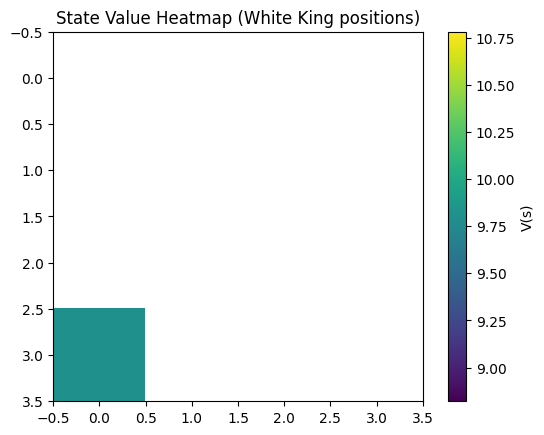


Running Policy Iteration...
[Policy Iteration] Iteration 1, stable=False
[Policy Iteration] Iteration 2, stable=False
[Policy Iteration] Iteration 3, stable=False
[Policy Iteration] Iteration 4, stable=False
[Policy Iteration] Iteration 5, stable=False
[Policy Iteration] Iteration 6, stable=True

Policy Trace using Policy Iteration:

=== POLICY TRACE START ===
. . . k
. . . .
. . . .
K P . .

Step 0: Action(piece='P', from_pos=(3, 1), to_pos=(2, 1))
. . k .
. . . .
. P . .
K . . .

Step 1: Action(piece='K', from_pos=(3, 0), to_pos=(2, 1))
. k . .
. . . .
. P . .
. . . .

Step 2: Action(piece='P', from_pos=(2, 1), to_pos=(1, 1))
. k . .
. P . .
. K . .
. . . .

Episode finished with reward: 10.0
=== POLICY TRACE END ===



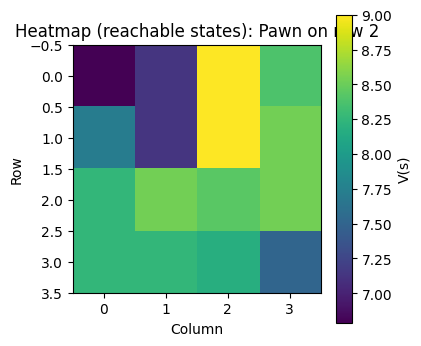

In [30]:
# Main Usage - 1 mark

if __name__ == "__main__":
    # Initial state based on even number
    env = MiniChessEnv()
    init_state = env.reset()

    # List reachable states
    indexer = StateIndexer(env, init_state)
    print("Total reachable states:", len(indexer.idx_to_state))

    # Run value or policy iteration on reachable states
    print("\nRunning Value Iteration...")
    V, policy_vi = value_iteration(indexer)

    print("\nPolicy Trace from Initial State:")
    generate_policy_trace(env, indexer, policy_vi, init_state)

    # Visualize
    plot_value(indexer, V, init_state.wp, init_state.bk)

    print("\nRunning Policy Iteration...")
    V_pi, policy_pi = policy_iteration(indexer)

    print("\nPolicy Trace using Policy Iteration:")
    generate_policy_trace(env, indexer, policy_pi, init_state)

    plot_value_heatmap_from_reachable(indexer, V, pawn_row=2)

## Part 8 : Result Discussion & Conclusion

- <ins>Conclusion and Analysis of Results:</ins>
  - Both **Value Iteration** and **Policy Iteration** converged and produced the same optimal policy.
  - THe learned policy shows that agent **prioritizes advancing the pawn while positioning the white king to support promotion and restrict the black king**, which leads to a guaranteed win with reward **+10.**
  - After pawn promotion, the agent **transitions to a mating strategy**, demonstrating correct long-term planning.


- <ins>Comparision bet Value vs Policy Iteration:</ins>
  - Policy iteration converged in fewer outer iterations compared to value iteration.
  - Although each iteration was computationally more expensive due to policy evaluation.

- <ins>Effect of State Design and Reward Shaping:</ins>
  - The state representation is fully Markovian, including piece positions, turn, promotion status, and move count.
  - Tracking pawn promotion allows the agent to adapt its strategy after promotion.
  - A **sparse reward design** encourages long-term planning rather than short-term moves.
  - Strong terminal rewards enable fast value propagation, leading to efficient convergence.  


- <ins>Structural Patterns Observed in the State-Value Function:<ins>


  * State values are **higher when the White King is closer to the pawn**, as it can support pawn movement and promotion more effectively.
  * Values are **lower when the White King is far from the pawn or placed near board edges**, where it cannot help the pawn and allows the Black King to block it.
  * Positions where the **Black King is farther away from the pawn's promotion path** have higher values, as White has a clearer winning strategy.
  * The smooth change in values across the board shows that **DP has correctly propagated long-term rewards**, capturing key chess endgame ideas such as king activity and pawn support.




## Part 9 Result Discussion: State Design & DP Limits (1 mark)

### Curse of Dimensionality

* On a **4X4 board**, the number of states is small because each piece has very few possible squares.

* If the board is increased to **8X8**, each piece can occupy many more positions, so the total number of states increases **exponentially**.

* Adding more pieces (such as a **rook or another pawn**) multiplies the state space further, as every extra piece can appear in many board positions.

* Due to this rapid growth, storing and updating values for all states becomes **computationally infeasible**.

### Is Dynamic Programming Enough for Full Chess?

* Dynamic Programming is **not feasible for full chess** because the number of possible states is extremely large.

* DP requires storing and updating the value of **every possible state**, which is impossible for full chess.

* Modern RL methods avoid this by:
  * Using **Monte Carlo Tree Search (MCTS)** to explore only promising moves.
  * Using **function approximation (neural networks)** instead of storing values for all states.

* This MiniChess implementation demonstrates the **core idea** behind these methods but on a much smaller and manageable state space.